In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [73]:
df_men =pd.read_csv(r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/Hillstrom-Men.csv")


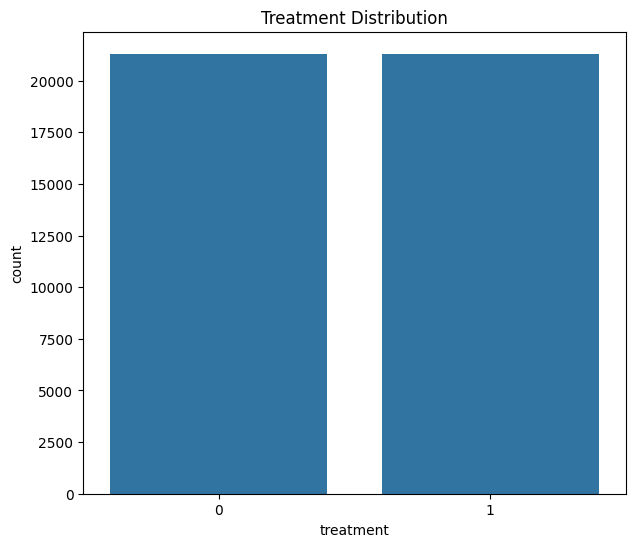

In [74]:
plt.figure(figsize=(7,6))
sns.countplot(data = df_men, x = 'treatment')
plt.title("Treatment Distribution")
plt.show()

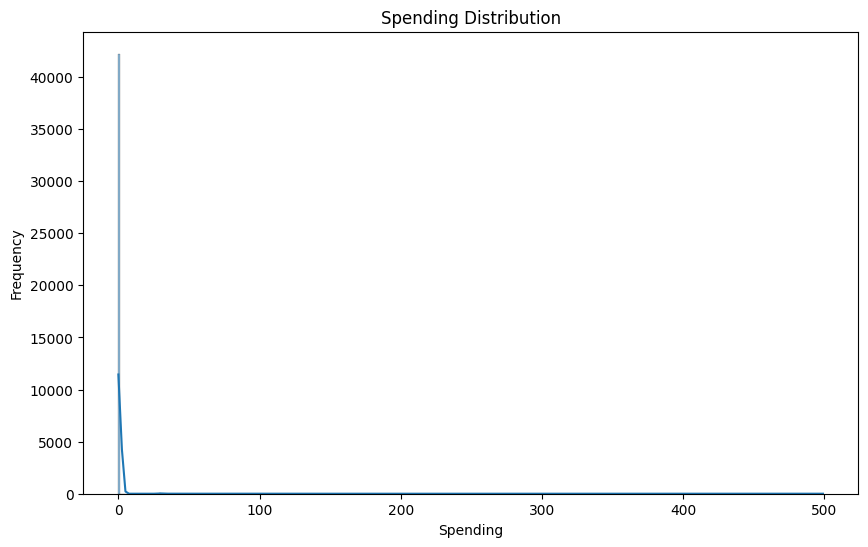

In [75]:
plt.figure(figsize=(10,6))
sns.histplot(data= df_men, x="spend", kde=True)
plt.title('Spending Distribution')
plt.xlabel('Spending')
plt.ylabel('Frequency')
plt.show()

spend
0.00      42224
29.99        96
30.24         1
30.94         1
30.98         1
          ...  
421.76        1
444.33        1
444.92        1
482.31        1
499.00        8
Name: count, Length: 288, dtype: int64
Percentage of customers who didn't spend: 99.08713303451998%


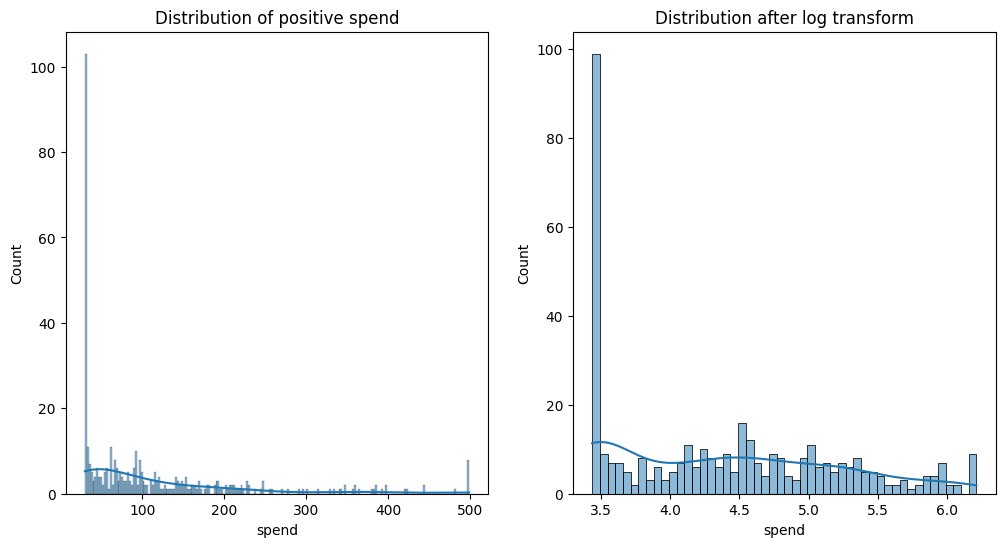

In [76]:
#EDA Spend
spend_count = df_men["spend"].value_counts()
print(spend_count.sort_index())

zero_fraction  = (df_men["spend"]==0).mean()
print (f"Percentage of customers who didn't spend: {zero_fraction*100}%")

positive_spend = df_men[df_men["spend"]>0]["spend"]

fig, axes = plt.subplots(1,2, figsize=(12,6))

sns.histplot(data= positive_spend, bins = 200, ax=axes[0], kde = True)
axes[0].set_title("Distribution of positive spend")

sns.histplot(data= np.log1p(positive_spend), bins = 50, ax=axes[1], kde=True)
axes[1].set_title("Distribution after log transform")
plt.show()

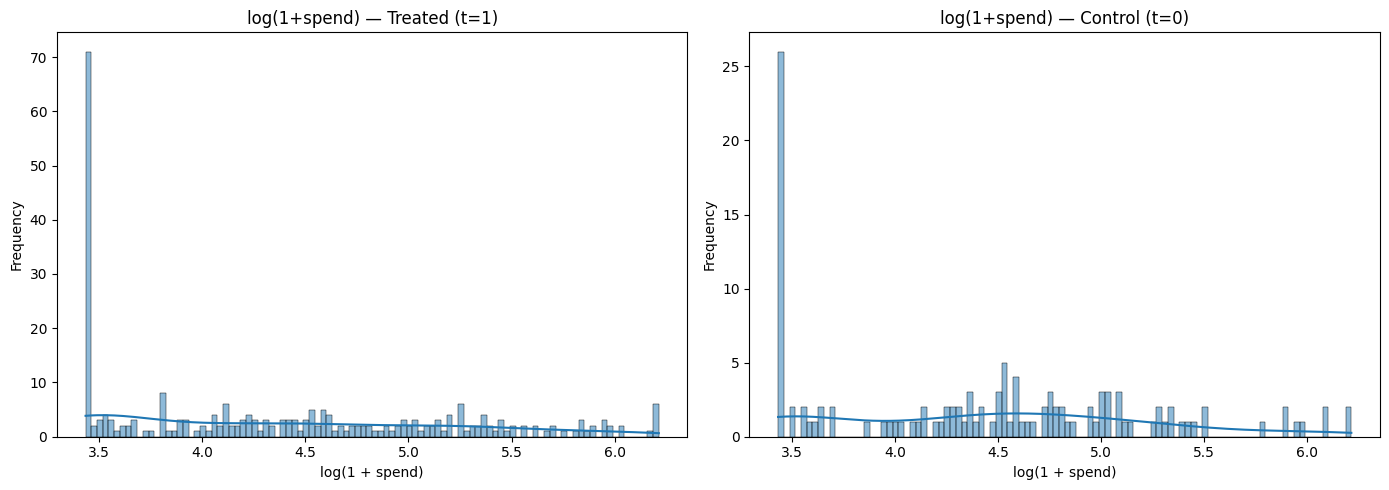

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group, label in zip(axes, [1, 0], ["Treated (t=1)", "Control (t=0)"]):
    pos = df_men.loc[(df_men["treatment"] == group) & (df_men["spend"] > 0), "spend"]
    sns.histplot(np.log1p(pos), bins=100, kde=True, ax=ax)
    ax.set_title(f"log(1+spend) — {label}")
    ax.set_xlabel("log(1 + spend)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

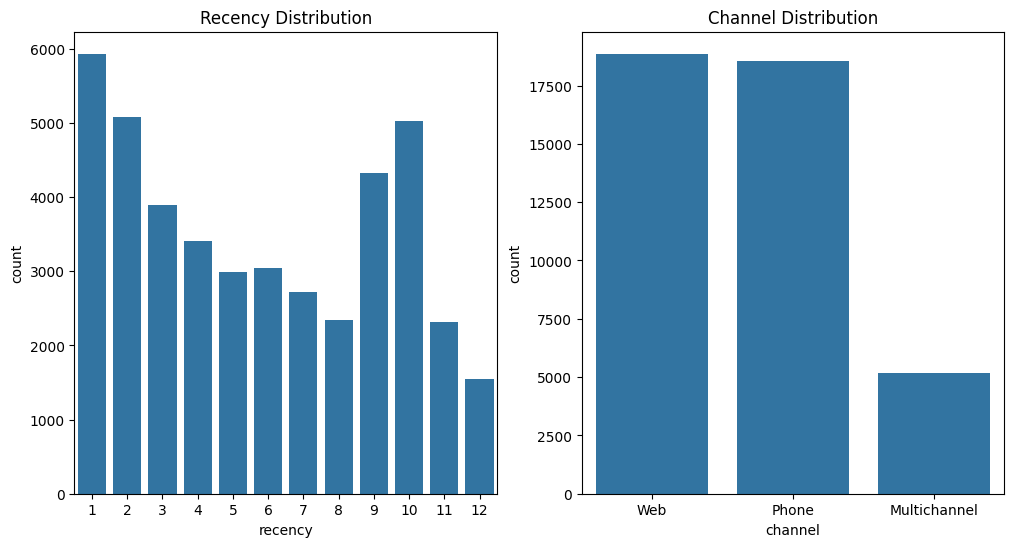

In [78]:
fig, axes = plt.subplots(1,2, figsize=(12,6))
sns.countplot(data = df_men, x = 'recency', ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.countplot(data = df_men, x = "channel", ax=axes[1])
axes[1].set_title("Channel Distribution")

plt.show()

In [79]:
# ═══════════════════════════════════════════════════════════════════════════
# ATE & KEY STATISTICS — Hillstrom Men
# ═══════════════════════════════════════════════════════════════════════════

t = df_men["treatment"].values
y = df_men["spend"].values

# ── 1. ATE (Average Treatment Effect) ────────────────────────────────────
ate_spend = y[t == 1].mean() - y[t == 0].mean()
print("=" * 60)
print("ATE (Average Treatment Effect)")
print("=" * 60)
print(f"  Avg spend (treated):  {y[t==1].mean():.4f}")
print(f"  Avg spend (control):  {y[t==0].mean():.4f}")
print(f"  ATE (spend):          {ate_spend:.4f}")
print(f"  ATE > 0 → email campaign {'INCREASES' if ate_spend > 0 else 'DECREASES'} spending")

# ── 2. Conversion-based ATE ──────────────────────────────────────────────
conv = df_men["conversion"].values
ate_conv = conv[t == 1].mean() - conv[t == 0].mean()
print(f"\n  Conversion rate (treated): {conv[t==1].mean():.4%}")
print(f"  Conversion rate (control): {conv[t==0].mean():.4%}")
print(f"  ATE (conversion):          {ate_conv:.4%}")

# ── 3. Visit-based ATE ───────────────────────────────────────────────────
visit = df_men["visit"].values
ate_visit = visit[t == 1].mean() - visit[t == 0].mean()
print(f"\n  Visit rate (treated): {visit[t==1].mean():.4%}")
print(f"  Visit rate (control): {visit[t==0].mean():.4%}")
print(f"  ATE (visit):          {ate_visit:.4%}")

# ── 4. Dataset overview ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print(f"{'='*60}")
print(f"  Total samples:      {len(df_men)}")
print(f"  Treated:            {(t==1).sum()} ({(t==1).mean():.1%})")
print(f"  Control:            {(t==0).sum()} ({(t==0).mean():.1%})")
print(f"  Zero spend:         {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  Positive spend:     {(y>0).sum()} ({(y>0).mean():.1%})")

# ── 5. Spend distribution by group ───────────────────────────────────────
print(f"\n{'='*60}")
print("SPEND BY GROUP")
print(f"{'='*60}")
for group, label in [(1, "Treated"), (0, "Control")]:
    yg = y[t == group]
    pos = yg[yg > 0]
    print(f"\n  {label}:")
    print(f"    Mean spend (all):      {yg.mean():.4f}")
    print(f"    Median spend (all):    {np.median(yg):.4f}")
    print(f"    Std spend (all):       {yg.std():.4f}")
    print(f"    Positive rate:         {(yg>0).mean():.4%}")
    if len(pos) > 0:
        print(f"    Mean spend (if > 0):   {pos.mean():.4f}")
        print(f"    Median spend (if > 0): {np.median(pos):.4f}")
    print(f"    Max spend:             {yg.max():.4f}")

# ── 6. Statistical significance ──────────────────────────────────────────
from scipy.stats import ttest_ind, mannwhitneyu
print(f"\n{'='*60}")
print("STATISTICAL SIGNIFICANCE")
print(f"{'='*60}")
t_stat, p_val = ttest_ind(y[t==1], y[t==0])
print(f"  t-test (spend):      t={t_stat:.4f}, p={p_val:.4f} {'✅ Sig' if p_val < 0.05 else '❌ Not sig'}")

u_stat, p_val_u = mannwhitneyu(y[t==1], y[t==0], alternative='two-sided')
print(f"  Mann-Whitney (spend): U={u_stat:.0f}, p={p_val_u:.4f} {'✅ Sig' if p_val_u < 0.05 else '❌ Not sig'}")

t_stat_c, p_val_c = ttest_ind(conv[t==1], conv[t==0])
print(f"  t-test (conversion): t={t_stat_c:.4f}, p={p_val_c:.4f} {'✅ Sig' if p_val_c < 0.05 else '❌ Not sig'}")

ATE (Average Treatment Effect)
  Avg spend (treated):  1.4226
  Avg spend (control):  0.6528
  ATE (spend):          0.7698
  ATE > 0 → email campaign INCREASES spending

  Conversion rate (treated): 1.2531%
  Conversion rate (control): 0.5726%
  ATE (conversion):          0.6805%

  Visit rate (treated): 18.2757%
  Visit rate (control): 10.6167%
  ATE (visit):          7.6590%

DATASET OVERVIEW
  Total samples:      42613
  Treated:            21307 (50.0%)
  Control:            21306 (50.0%)
  Zero spend:         42224 (99.1%)
  Positive spend:     389 (0.9%)

SPEND BY GROUP

  Treated:
    Mean spend (all):      1.4226
    Median spend (all):    0.0000
    Std spend (all):       17.7538
    Positive rate:         1.2531%
    Mean spend (if > 0):   113.5269
    Median spend (if > 0): 66.9800
    Max spend:             499.0000

  Control:
    Mean spend (all):      0.6528
    Median spend (all):    0.0000
    Std spend (all):       11.5879
    Positive rate:         0.5726%
    Mean 

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Giả sử df_men đã được load trước đó
# split num and cate
cate_cols = ['channel']
num_cols = ['recency', 'history', 'history_segment', "zip_code"]

# split x, treatment và labels
y_men = df_men["spend"]
t_men = df_men["treatment"]
conv_men = df_men["conversion"]
visit_men = df_men["visit"]
x_men = df_men.drop(columns=["spend", "treatment", "conversion", "visit"])

# Tạo biến stratify kết hợp: treatment x purchase (y > 0)
stratify_combined = t_men.astype(str) + "_" + (y_men > 0).astype(int).astype(str)

# train test split - stratify bằng treatment x purchase
(
    x_men_train,
    x_men_test,
    t_men_train,
    t_men_test,
    y_men_train,
    y_men_test,
    conv_men_train,
    conv_men_test,
    visit_men_train,
    visit_men_test,
) = train_test_split(
    x_men,
    t_men.values,
    y_men.values,
    conv_men.values,
    visit_men.values,
    test_size=0.3,
    random_state=42,
    stratify=stratify_combined,
)

# Tạo stratify cho val split - treatment x purchase
stratify_var_train = pd.Series(t_men_train).astype(str) + "_" + (pd.Series(y_men_train) > 0).astype(int).astype(str)

# Chia tiếp tập train thành train và val (1/7 của 0.7 tương đương 0.1 của tổng)
(
    x_men_train,
    x_men_val,
    t_men_train,
    t_men_val,
    y_men_train,
    y_men_val,
    conv_men_train,
    conv_men_val,
    visit_men_train,
    visit_men_val,
) = train_test_split(
    x_men_train,
    t_men_train,
    y_men_train,
    conv_men_train,
    visit_men_train,
    test_size=(1/7),
    random_state=42,
    stratify=stratify_var_train,
)

# Fit get_dummies trên train, sau đó align với val/test
x_men_train_encode = pd.get_dummies(x_men_train, columns=cate_cols, drop_first=False)
x_men_val_encode = pd.get_dummies(x_men_val, columns=cate_cols, drop_first=False)
x_men_test_encode = pd.get_dummies(x_men_test, columns=cate_cols, drop_first=False)

# Align columns
x_men_val_encode = x_men_val_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)
x_men_test_encode = x_men_test_encode.reindex(columns=x_men_train_encode.columns, fill_value=0)

scaler = StandardScaler()
x_men_train = scaler.fit_transform(x_men_train_encode)
x_men_val = scaler.transform(x_men_val_encode)
x_men_test = scaler.transform(x_men_test_encode)

print("✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE")
print(f"Train: {x_men_train.shape}, Val: {x_men_val.shape}, Test: {x_men_test.shape}")
print(f"Treatment distribution - Train: {np.mean(t_men_train):.2%}, Val: {np.mean(t_men_val):.2%}, Test: {np.mean(t_men_test):.2%}")
print(f"Purchase rate - Train: {np.mean(y_men_train > 0):.2%}, Val: {np.mean(y_men_val > 0):.2%}, Test: {np.mean(y_men_test > 0):.2%}")
print(f"Spend mean - Train: {np.mean(y_men_train):.2f}, Val: {np.mean(y_men_val):.2f}, Test: {np.mean(y_men_test):.2f}")
print(f"Conversion rate - Train: {np.mean(conv_men_train):.2%}, Val: {np.mean(conv_men_val):.2%}, Test: {np.mean(conv_men_test):.2%}")
print(f"Visit rate - Train: {np.mean(visit_men_train):.2%}, Val: {np.mean(visit_men_val):.2%}, Test: {np.mean(visit_men_test):.2%}")

✅ Train/Val/Test split with stratification by TREATMENT x PURCHASE
Train: (25567, 11), Val: (4262, 11), Test: (12784, 11)
Treatment distribution - Train: 50.00%, Val: 50.00%, Test: 50.00%
Purchase rate - Train: 0.91%, Val: 0.92%, Test: 0.92%
Spend mean - Train: 1.06, Val: 1.05, Test: 0.99
Conversion rate - Train: 0.91%, Val: 0.92%, Test: 0.92%
Visit rate - Train: 14.47%, Val: 14.69%, Test: 14.31%


In [81]:
import os

# Gom lại các features + treatment + labels thành DataFrame để lưu CSV
feature_cols = x_men_train_encode.columns

df_train = pd.DataFrame(x_men_train, columns=feature_cols)
df_train["treatment"] = t_men_train
df_train["spend"] = y_men_train
df_train["conversion"] = conv_men_train
df_train["visit"] = visit_men_train

df_val = pd.DataFrame(x_men_val, columns=feature_cols)
df_val["treatment"] = t_men_val
df_val["spend"] = y_men_val
df_val["conversion"] = conv_men_val
df_val["visit"] = visit_men_val

df_test = pd.DataFrame(x_men_test, columns=feature_cols)
df_test["treatment"] = t_men_test
df_test["spend"] = y_men_test
df_test["conversion"] = conv_men_test
df_test["visit"] = visit_men_test

# Drop các cột Unnamed nếu có trước khi lưu
for _df in [df_train, df_val, df_test]:
    unnamed_cols = [c for c in _df.columns if str(c).lower().startswith("unnamed")]
    if unnamed_cols:
        _df.drop(columns=unnamed_cols, inplace=True)

# Export ra thư mục hiện tại
save_dir = r"/home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men"

train_path = os.path.join(save_dir, "train_men.csv")
val_path = os.path.join(save_dir, "val_men.csv")
test_path = os.path.join(save_dir, "test_men.csv")

df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path, index=False)
df_test.to_csv(test_path, index=False)

print(f"✅ Đã lưu tập Train Data tại: {train_path}")
print(f"✅ Đã lưu tập Val Data tại: {val_path}")
print(f"✅ Đã lưu tập Test Data tại: {test_path}")
print(f"Columns - Train: {df_train.shape[1]}, Val: {df_val.shape[1]}, Test: {df_test.shape[1]}")
print("Included labels: spend, conversion, visit")

✅ Đã lưu tập Train Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/train_men.csv
✅ Đã lưu tập Val Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/val_men.csv
✅ Đã lưu tập Test Data tại: /home/ducvu0904/Documents/Lab/Conversion vs revenue benchmarking/dataset/Hillstrom/Men/test_men.csv
Columns - Train: 14, Val: 14, Test: 14
Included labels: spend, conversion, visit


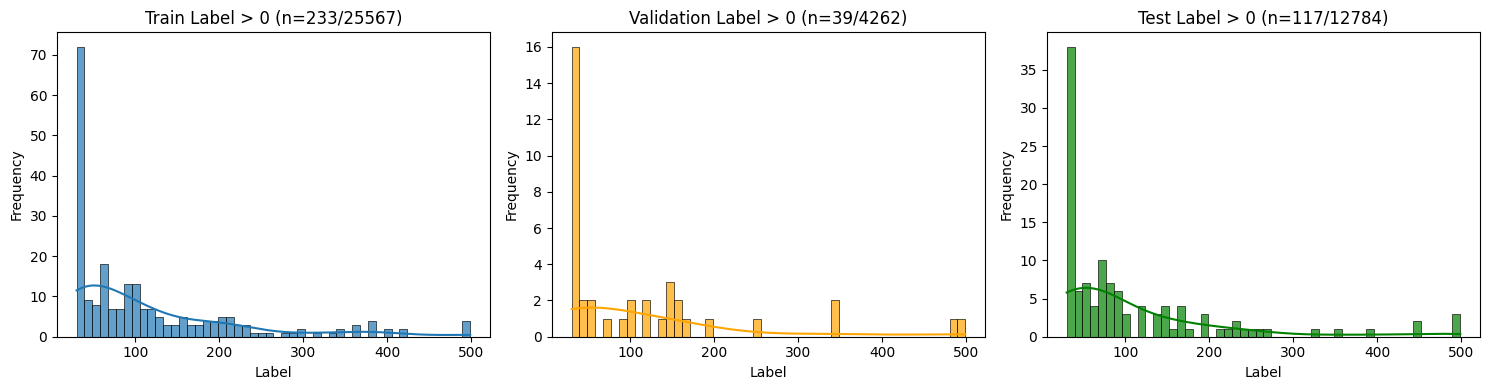

Train (>0) - Mean: 116.2666, Std: 107.2064, Min: 29.9900, Max: 499.0000
Val   (>0) - Mean: 114.2933, Std: 119.1547, Min: 29.9900, Max: 499.0000
Test  (>0) - Mean: 108.3117, Std: 108.0414, Min: 29.9900, Max: 499.0000


In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only values > 0
y_train_pos = y_men_train[y_men_train > 0]
y_val_pos = y_men_val[y_men_val > 0]
y_test_pos = y_men_test[y_men_test > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
sns.histplot(y_train_pos, bins=50, kde=True, ax=axes[0], alpha=0.7, edgecolor='black')
axes[0].set_title(f'Train Label > 0 (n={len(y_train_pos)}/{len(y_men_train)})')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Frequency')

# Validation
sns.histplot(y_val_pos, bins=50, kde=True, ax=axes[1], alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title(f'Validation Label > 0 (n={len(y_val_pos)}/{len(y_men_val)})')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Frequency')

# Test
sns.histplot(y_test_pos, bins=50, kde=True, ax=axes[2], alpha=0.7, color='green', edgecolor='black')
axes[2].set_title(f'Test Label > 0 (n={len(y_test_pos)}/{len(y_men_test)})')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Train (>0) - Mean: {y_train_pos.mean():.4f}, Std: {y_train_pos.std():.4f}, Min: {y_train_pos.min():.4f}, Max: {y_train_pos.max():.4f}")
print(f"Val   (>0) - Mean: {y_val_pos.mean():.4f}, Std: {y_val_pos.std():.4f}, Min: {y_val_pos.min():.4f}, Max: {y_val_pos.max():.4f}")
print(f"Test  (>0) - Mean: {y_test_pos.mean():.4f}, Std: {y_test_pos.std():.4f}, Min: {y_test_pos.min():.4f}, Max: {y_test_pos.max():.4f}")

In [83]:
def compute_ate(y, t):
    y = np.asarray(y).reshape(-1)
    t = np.asarray(t).reshape(-1)
    treated = y[t == 1]
    control = y[t == 0]
    return treated.mean() - control.mean()

ate_train = compute_ate(y_men_train, t_men_train)
ate_val = compute_ate(y_men_val, t_men_val)
ate_test = compute_ate(y_men_test, t_men_test)

print(f"ATE (Train): {ate_train:.6f}")
print(f"ATE (Val):   {ate_val:.6f}")
print(f"ATE (Test):  {ate_test:.6f}")

ATE (Train): 0.828667
ATE (Val):   0.963970
ATE (Test):  0.587423


In [84]:
conversion_rates = {
    "Train": np.mean(conv_men_train),
    "Validation": np.mean(conv_men_val),
    "Test": np.mean(conv_men_test),
}

for set_name, rate in conversion_rates.items():
    if set_name == "Train":
        conv_data = conv_men_train
    elif set_name == "Validation":
        conv_data = conv_men_val
    else:
        conv_data = conv_men_test
        
    print(f"{set_name} conversion rate: {rate:.4%} ({conv_data.sum()}/{len(conv_data)})")

Train conversion rate: 0.9113% (233/25567)
Validation conversion rate: 0.9151% (39/4262)
Test conversion rate: 0.9152% (117/12784)


In [1]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu
df = pd.read_csv('test_men.csv')

# 2. Lọc các mẫu có chi tiêu dương (Positive samples)
# Trong file của bạn, cột mục tiêu là 'spend'
positive_spend = df[df['spend'] > 0]['spend']

if len(positive_spend) > 0:
    # 3. Biến đổi Logarit
    log_positive_spend = np.log(positive_spend)

    # 4. Tính toán Muy (Mean của log values)
    target_mu = log_positive_spend.mean()

    # 5. Tính toán Sigma (Std của log values)
    target_sigma = log_positive_spend.std()

    print(f"Số mẫu dương: {len(positive_spend)} / {len(df)}")
    print(f"Target Muy (μ): {target_mu:.4f}")
    print(f"Target Sigma (σ): {target_sigma:.4f}")
else:
    print("Không có mẫu dương nào trong tập dữ liệu.")

Số mẫu dương: 117 / 12784
Target Muy (μ): 4.3167
Target Sigma (σ): 0.8235


In [2]:
import pandas as pd
import numpy as np

# 1. Load dữ liệu
df = pd.read_csv('train_men.csv')

# 2. Lọc các mẫu có chi tiêu dương (Positive samples)
# Trong file của bạn, cột mục tiêu là 'spend'
positive_spend = df[df['spend'] > 0]['spend']

if len(positive_spend) > 0:
    # 3. Biến đổi Logarit
    log_positive_spend = np.log(positive_spend)

    # 4. Tính toán Muy (Mean của log values)
    target_mu = log_positive_spend.mean()

    # 5. Tính toán Sigma (Std của log values)
    target_sigma = log_positive_spend.std()

    print(f"Số mẫu dương: {len(positive_spend)} / {len(df)}")
    print(f"Target Muy (μ): {target_mu:.4f}")
    print(f"Target Sigma (σ): {target_sigma:.4f}")
else:
    print("Không có mẫu dương nào trong tập dữ liệu.")

Số mẫu dương: 233 / 25567
Target Muy (μ): 4.3952
Target Sigma (σ): 0.8375
